# Demo notebook snippet for manual trilateration input.


In [1]:
# Import the trilateration package
from trilaterate_moor import solve_anchor_position, dec2deg
from datetime import datetime



In [ ]:
# Survey positions and ranges
# Format: [latitude_degrees, latitude_minutes, longitude_degrees, longitude_minutes, range_meters]


In [ ]:


# Survey parameters
release_height = 7         # Height of acoustic release above seafloor (m)
transducer_depth = 7.7        # Depth of ship's transducer below surface (m)
         # Location name

# Survey positions and ranges
# Format: [latitude_degrees, latitude_minutes, longitude_degrees,

# Sound speed (m/s) - adjust for your area
true_sound_speed = 1490  # Use 1495 for FC3, 1503 for most other sites

water_depth_anchor_launch = 690  # Water depth at anchor deployment (m)
loc_name = "dsG1"
survey_data = [
    # Anchor deployment (range = 0)
    [65, 35.42, -29, -27.47, 0],

    # Position fixes with acoustic ranges
    [65, 35.2656, -29, -27.0447, 936],  # Fix 1
    [65, 35.6567, -29, -27.5268, 900],  # Fix 2
    [65, 35.3346, -29, -28.0173, 755],  # Fix 3
    [65, 35.2882, -29, -28.2560, 850]   # Fix 4
]
# =============================================================================
# PROCESSING SECTION - No need to edit below this line
# =============================================================================

def convert_to_decimal_degrees(deg, min_val):
    """Convert degrees and decimal minutes to decimal degrees."""
    return deg + min_val/60

def convert_from_decimal_degrees(decimal_degrees):
    """Convert decimal degrees back to degrees and decimal minutes."""
    abs_val = abs(decimal_degrees)
    degrees = int(abs_val)
    minutes = (abs_val - degrees) * 60
    return degrees, minutes

# Convert survey data to the format expected by solve_anchor_position
latitudes = []
longitudes = []
ranges = []

print(f"Processing survey data for {loc_name}:")
#print("-" * 50)

for i, (lat_deg, lat_min, lon_deg, lon_min, range_val) in enumerate(survey_data):
    # Convert to decimal degrees
    lat_decimal = convert_to_decimal_degrees(lat_deg, lat_min)
    lon_decimal = convert_to_decimal_degrees(lon_deg, lon_min)

    latitudes.append(lat_decimal)
    longitudes.append(lon_decimal)
    ranges.append(range_val)

    if range_val == 0:
        print(f"Deployment: {lat_decimal:.5f}°N, {lon_decimal:.5f}°W ({lat_deg}°{lat_min:.2f}'N, {abs(lon_deg)}°{abs(lon_min):.2f}'W)")
    else:
        print(f"Fix {i}: {lat_decimal:.5f}°N, {lon_decimal:.5f}°W ({lat_deg}°{lat_min:.2f}'N, {abs(lon_deg)}°{abs(lon_min):.2f}'W) - Range: {range_val}m")

# Create triangulation data structure
triang_data = {
    'loc_name': loc_name,
    'release_height': release_height,
    'transducer_depth': transducer_depth,
    'water_depth_anchor_launch': water_depth_anchor_launch,
    'times': [datetime.now()] * len(ranges),  # Dummy times
    'ranges': ranges,
    'latitudes': latitudes,
    'longitudes': longitudes
}

print("\nSurvey parameters:")
print(f"  Water depth: {water_depth_anchor_launch}m")
print(f"  Release height: {release_height}m")
print(f"  Transducer depth: {transducer_depth}m")
print(f"  Sound speed: {true_sound_speed}m/s")

# Solve for anchor position
print("\nSolving trilateration...")
solution = solve_anchor_position(triang_data, true_sound_speed=true_sound_speed)

# Display results
print("\n" + "="*60)
print(f"ANCHOR POSITION RESULTS FOR {loc_name}")
print("="*60)

anchor_lat = solution['anchor_lat']
anchor_lon = solution['anchor_lon']

print(f"Decimal degrees: {anchor_lat:.6f}°N, {anchor_lon:.6f}°W")

# Convert to degrees/minutes format
_, _, lat_str = dec2deg(anchor_lat)
_, _, lon_str = dec2deg(abs(anchor_lon))
print(f"Degrees/minutes: {lat_str}N, {lon_str}W")

print("\nQuality metrics:")
print(f"  Fallback distance: {solution['fallback_distance']:.0f} m")
print(f"  Max residual error: {solution['max_residual']:.1f} m")
print(f"  RMS residual error: {solution['rms_residual']:.1f} m")

print("\nIndividual fix residuals:")
for i, residual in enumerate(solution['residuals']):
    print(f"  Fix {i+1}: {residual:.1f} m")

# Check survey quality
if solution['rms_residual'] < 10:
    quality = "Excellent"
elif solution['rms_residual'] < 50:
    quality = "Good"
elif solution['rms_residual'] < 100:
    quality = "Fair"
else:
    quality = "Poor"

print(f"\nSurvey quality: {quality}")
print("="*60)



Processing survey data for dsG1:
Deployment: 65.59033°N, -29.45783°W (65°35.42'N, 29°27.47'W)
Fix 1: 65.58776°N, -29.45075°W (65°35.27'N, 29°27.04'W) - Range: 936m
Fix 2: 65.59428°N, -29.45878°W (65°35.66'N, 29°27.53'W) - Range: 900m
Fix 3: 65.58891°N, -29.46695°W (65°35.33'N, 29°28.02'W) - Range: 755m
Fix 4: 65.58814°N, -29.47093°W (65°35.29'N, 29°28.26'W) - Range: 850m

Survey parameters:
  Water depth: 690m
  Release height: 7m
  Transducer depth: 7.7m
  Sound speed: 1490m/s

Solving trilateration...

ANCHOR POSITION RESULTS FOR dsG1
Decimal degrees: 65.589775°N, -29.462412°W
Degrees/minutes: 65°35.39'N, 29°27.74'W

Quality metrics:
  Fallback distance: 220 m
  Max residual error: 87.4 m
  RMS residual error: 65.3 m

Individual fix residuals:
  Fix 1: 49.5 m
  Fix 2: 50.1 m
  Fix 3: 87.4 m
  Fix 4: 66.8 m

Survey quality: Fair


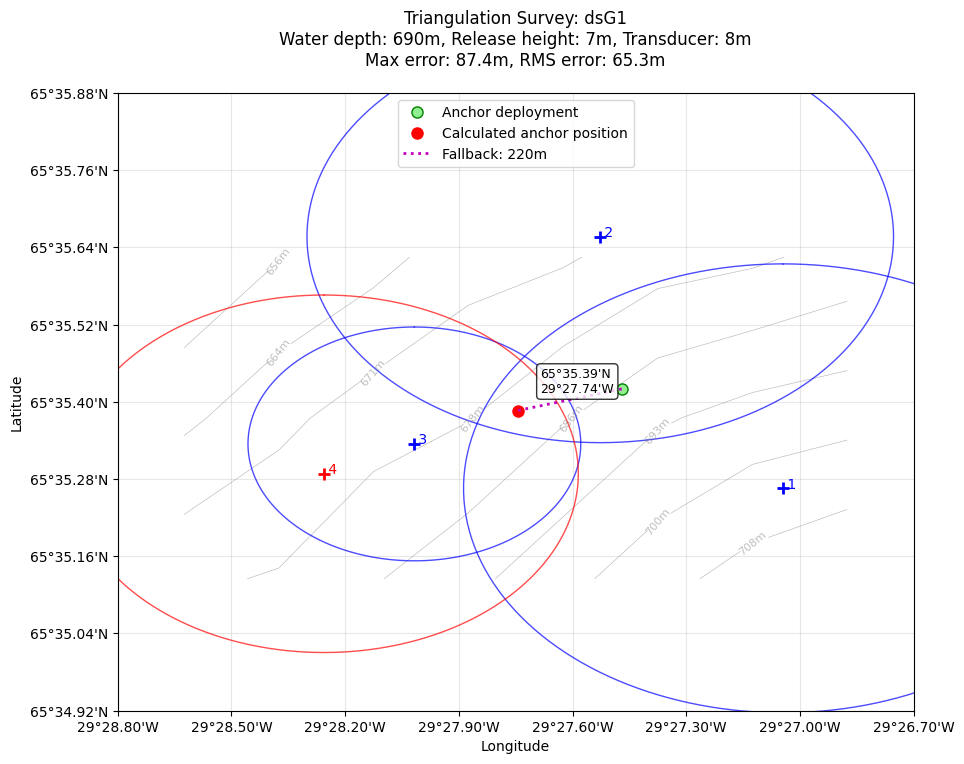

In [4]:
from trilaterate_moor import plot_trilateration_survey
from trilaterate_moor import load_bathymetry_netcdf
import matplotlib.pyplot as plt
#fig = plot_trilateration_survey(triang_data, solution, save_figure="anchor_survey.png")
# Option 1: Load bathymetry automatically from NetCDF
#bathymetry_path = "../../cruiseplan/data/bathymetry/msm142_bathyJJ.nc"
bathymetry_path = "../../cruiseplan/data/bathymetry/GEBCO_2025.nc"
bathy = load_bathymetry_netcdf(bathymetry_path)
fig = plot_trilateration_survey(triang_data, solution, bathymetry=bathy)

  #fig = plot_trilateration_survey(triang_data, solution, bathymetry=bathymetry_path)
plt.show()

#fig = plot_trilateration_survey(triang_data, solution, save_figure="../figs/dsG1_trilateration.png")
#plt.show()
